<font color="teal" size=9>Copy code from 1D GD</font>


1) Time (training epoch)
2) Derivative
3) Loss
4) Current local minimum value







<font size=5>Running experiments to understand GD</font>

Create the range of x. I.e simulated data IMU

In [77]:
import numpy as np
import matplotlib.pyplot as plt 
import sympy as sym # sympy to compute the partial derivatives

from IPython import display 
display.set_matplotlib_formats('svg')


# define range for x
x = np.linspace(-2,2,2001)

def fx(x):
    return 3*x**2 - 3*x + 4

def deriv(x):
    return 6*x - 3



C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\3221617868.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


G.D. using a fixed learning rate

In [78]:

# random starting point
localmin = np.random.choice(x,1)
initval = localmin[:] # store the init value

# learning parameters
learning_rate = 0.01
training_epochs = 50

# run through training and store all the results
modelparamsFixed= np.zeros((training_epochs,3))
for i in range(training_epochs):
    # compute gradient
    grad = deriv(localmin)

    # non-adaptive learning rate
    lr = learning_rate

    # update parameter according to g.d.
    localmin = localmin - lr*grad
  #  print(i,localmin,grad,lr)

    # store the parameters
    modelparamsFixed[i,0] = localmin
    modelparamsFixed[i,1] = grad
    modelparamsFixed[i,2] = lr

#print(modelparamsFixed)


C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\1602157472.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  modelparamsFixed[i,0] = localmin
C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\1602157472.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  modelparamsFixed[i,1] = grad


G.D. usin g a gradient-based learning rate

Well, the idea here is that when we are very far away from the minimum, the function minimum, the gradient is relatively large.
So then the gradient is relatively large, which means that we are far away from where we need to be.

So that means the learning rate is relatively larger. Conversely, the closer we get to the actual function minimum, the gradient gets closer and closer to zero. It might be negative or it might be positive, but the magnitude of the gradient is getting smaller and smaller.

It's getting closer to zero. So that means that the effective learning rate that we use in gradient descent actually decreases,
the learning rate is gonna go towards zero as the gradient gets smaller.

So that's a pretty useful concept in deep learning that the learning rate should be larger the further you are away from the final solution, and it should get smaller as you get closer to a good minimum, a good solution.

In [79]:
# Same code as above, the only difference is we are changing the learning rate. of course we changed the name of modelparams
# random starting point
localmin = np.random.choice(x,1)
initval = localmin[:] # store the initial value

# learning parameters
learning_rate = 0.01
training_epochs = 50

# run through traiing and store all results
modelparamsGrad = np.zeros((training_epochs,3))
for i in range(training_epochs):

    # compute gradient. The learning rate is scaled by the derivative 
    lr = learning_rate*np.abs(grad) # abs cause we want to avoid ascent!! We want descent, hence GD!

    # update paramete raccording to GD
    localmin = localmin - lr*grad

    # store the parameters
    modelparamsGrad[i,0] = localmin
    modelparamsGrad[i,1] = grad
    modelparamsGrad[i,2] = lr

C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\927491881.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  modelparamsGrad[i,0] = localmin
C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\927491881.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  modelparamsGrad[i,1] = grad
C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\927491881.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  modelparamsGrad[i,2] = lr


<font color='teal' size=7>GD using time-based learning rate</font>

See how the  looping index increases, we get higher and higher closer to the number 50. And that means that this ratio here gets closer and closer to one, right? Because we're dividing the current index by the total number of training epics.

This gets close to one, and then we subtract that off. So that means that this quantity is getting closer to zero, which means that the effective learning rate is decreasing as the learning increases.

So you can see that this method here, adjusting the learning rate according to the time or training epoch, and this method up here of adjusting the learning rate according to the gradient, they both have a similar effect, which is to decrease the learning rate
as learning progresses and the mechanism is slightly different.

C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\1194235827.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  modelparamsTime[i,0] = localmin
C:\Users\mpere\AppData\Local\Temp\ipykernel_29556\1194235827.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  modelparamsTime[i,1] = grad


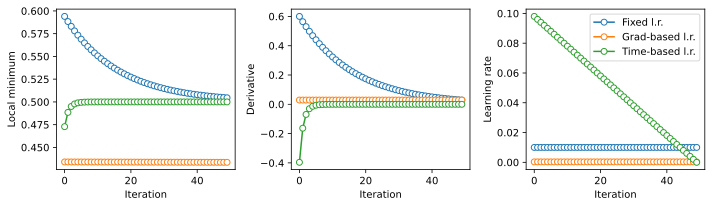

In [80]:

# redefine parameters
learning_rate = 0.1
localmin =  initval


# run through traiing and store all results
modelparamsTime = np.zeros((training_epochs,3))
for i in range(training_epochs):
    grad = deriv(localmin)
    lr = learning_rate*(1-(i+1)/training_epochs)
    localmin = localmin - lr*grad
    # store the parameters
    modelparamsTime[i,0] = localmin
    modelparamsTime[i,1] = grad
    modelparamsTime[i,2] = lr

fig,ax = plt.subplots(1,3,figsize=(10,3))

for i in range(3):
    ax[i].plot(modelparamsFixed[:,i],'o-',markerfacecolor='w')
    ax[i].plot(modelparamsGrad[:,i],'o-',markerfacecolor='w')
    ax[i].plot(modelparamsTime[:,i],'o-',markerfacecolor='w')
    ax[i].set_xlabel('Iteration')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')
ax[2].set_ylabel('Learning rate')
ax[2].legend(['Fixed l.r.', 'Grad-based l.r.','Time-based l.r.'])

plt.tight_layout()
plt.show()

<font color="teal" size=8> Summary and thoughts</font>

Possible ways to proportionate the learnign rate:

- Training epoch: Good method, often done in blocks. But unrelated to model performance/accuracy
- Derivative: Adaptive to the problem. Requires additional parameters and appropriate scaling
    
    *You can imagine if the derivative were some large number like four or 10 or a hundred, then we could actually be possibly even increasing the learning rate above one instead of decreasing the learning rate. So it requires appropriate scaling.*
- Loss (the diff between what we know is right answer and what model predicts): Adaptive to the problem. Works only when loss is in range of [0,1] (scaling possible)
- Current local minimum value: Adaptive to the problem. Too many assumptions for this generally to be a good idea.

A couple more notes. For 'training epoch' & 'Derivative' are industry standard ways to change the learning rate as a function of training and model performance. 'Training epoch' is called 'learning rate decay' and 'derivative' which is changing the learning rate according to the derivative is a method that is used/incorporated into methods such as RMSprop and Adam optimzers.